In [1]:
import simsopt
from simsopt.configs.zoo import get_w7x_data

In [2]:
curves, currents, ma = get_w7x_data()

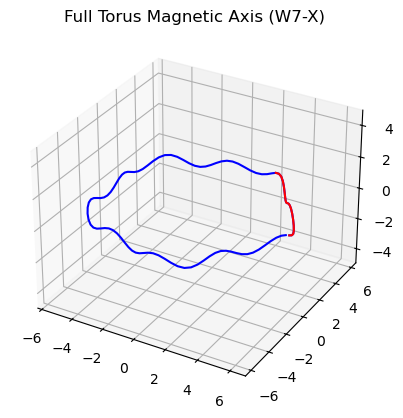

In [29]:
import numpy as np
import matplotlib.pyplot as plt
from simsopt.geo import Curve, CurveXYZFourier


# Number of field periods
N_PERIODS = 5

# Initialize list to store full torus points
full_axis_gamma = []
full_axis_gammadash = []

# Angle of rotation for each field period
rotation_angle = 2 * np.pi / N_PERIODS

# Replicate the half-period axis data
for n in range(N_PERIODS):
    # Rotate by n * rotation_angle
    R = np.array([
        [np.cos(n * rotation_angle), -np.sin(n * rotation_angle), 0],
        [np.sin(n * rotation_angle), np.cos(n * rotation_angle),  0],
        [0,                         0,                          1]
    ])
    rotated_gamma = np.dot(ma.gamma(), R.T)
    rotated_gammadash = np.dot(ma.gammadash(),R.T)

    full_axis_gamma.append(rotated_gamma)
    full_axis_gammadash.append(rotated_gammadash)

# Combine all periods
full_axis_gamma = np.concatenate(full_axis_gamma, axis=0)
full_axis_gammadash = np.concatenate(full_axis_gammadash, axis=0)
short_axis = ma.gamma()

order = 5       # Fourier order (controls smoothness)
nfp = 5         # Field periods (for W7-X)
N_points = full_axis_gamma.shape[0]  # Number of points along the curve




# Plotting
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.plot(full_axis_gamma[:, 0], full_axis_gamma[:, 1], full_axis_gamma[:, 2], 'b')
ax.plot(short_axis[:,0],short_axis[:,1],short_axis[:,2], 'r')

plt.axis('equal')

plt.title("Full Torus Magnetic Axis (W7-X)")

plt.show()


In [16]:
from simsopt.mhd.vmec import Vmec
import numpy as np

# Load W7X magnetic axis
curves, currents, ma = get_w7x_data()

# Set VMEC input parameters (initial guess for plasma boundary)
nfp = 5  # Number of field periods for W7-X
mpol = 8  # Poloidal resolution
ntor = 8  # Toroidal resolution

# VMEC equilibrium setup
stellsym = True
filename = '../../tests/test_files/input.W7-X_standard_configuration'
# load the surface
vmec = Vmec(filename)

# Run VMEC to compute equilibrium
vmec.run()

# Extract on-axis iota (at s=0)
iota_on_axis = vmec.wout.iotaf[0]

print(f"On-axis iota: {iota_on_axis:.6f}")


 - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - -
  SEQ =    1 TIME SLICE  0.0000E+00
  PROCESSING INPUT.W7-X_standard_configuration
  THIS IS PARVMEC (PARALLEL VMEC), VERSION 9.0
  Lambda: Full Radial Mesh. L-Force: hybrid full/half.

  COMPUTER: arm64-apple-darwin20.0.0   OS:    RELEASE:   DATE = Jan 07,2025  TIME = 17:59:48

  NS =   13 NO. FOURIER MODES =  200 FTOLV =  1.000E-07 NITER =  15000
  PROCESSOR COUNT - RADIAL:    1
 INITIAL JACOBIAN CHANGED SIGN!
 TRYING TO IMPROVE INITIAL MAGNETIC AXIS GUESS
  ---- Improved AXIS Guess ----
      RAXIS_CC =    5.5591727512474929       0.41452961849194375        1.1609726018948574E-002  -2.1708025323066767E-002  -1.3358227270700946E-002   4.3151610015397454E-003   5.6044505197274932E-003   2.2082752413610037E-003  -3.9278207404348890E-003  -4.5851423533295778E-003   5.8281416892341457E-003
      ZAXIS_CS =   -0.0000000000000000      -0.29905967304236764        3.9183371388715742E-002   3.7426693142503853E-002  -2.18705313

In [31]:
from simsopt.field.action import MagneticAction
from simsopt.field import ( BiotSavart, coils_via_symmetries)
coils = coils_via_symmetries(curves, currents, 5, True)
bs = BiotSavart(coils)
ncoils = len(coils)
bs = BiotSavart(coils)
bs.set_points(ma.gamma().reshape((-1, 3)))

axis_action = MagneticAction(ma, bs)

In [41]:
import jax.numpy as jnp
a = jnp.ones((1,3))
b = a
jnp.dot(a,b.T)

action = axis_action.J()
print(action)

TypeError: Cannot interpret value of type <class 'simsopt.field.biotsavart.BiotSavart'> as an abstract array; it does not have a dtype attribute